<a href="https://colab.research.google.com/github/Adityas221b/Pytorch/blob/main/CNN_MNIST_Practice.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [41]:
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import dataloader
# from torchvision  import datasets,transforms
from torchvision.utils import make_grid
import numpy as np
import pandas as pd
from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt
%matplotlib inline
from torch.utils.data import DataLoader

In [10]:
#CONVERT mnist image files into tensor of 4 channeels here (images ,height,width,collor cchannel)
transform =transforms.ToTensor()


In [15]:
#Train data
train_data =datasets.MNIST(root='cnn_data',train=True, download=True,transform=transform)

In [16]:
#Test data
test_data =datasets.MNIST(root='cnn_data',train=False, download=True,transform=transform)

In [17]:
train_data

Dataset MNIST
    Number of datapoints: 60000
    Root location: cnn_data
    Split: Train
    StandardTransform
Transform: ToTensor()

In [18]:
test_data

Dataset MNIST
    Number of datapoints: 10000
    Root location: cnn_data
    Split: Test
    StandardTransform
Transform: ToTensor()

In [100]:
##create a small batch size of omges say 10 here
train_loader= DataLoader(train_data,batch_size=10,shuffle=True)
test_loader= DataLoader(test_data,batch_size=10,shuffle=False)

In [46]:
###define CNN LAYER HERE

In [49]:
#describe convolutional layer and whats its doing (2 conv layer)
#this is just an


In [51]:
#asks for input out kernel size stride length
conv1 = nn.Conv2d(1,6,3,1)
conv2 = nn.Conv2d(6,16,3,1)

In [52]:
#GRAB 1 MNIST IMAGE /RECORD
for i,(X_train,y_train) in enumerate(train_data):
  break


In [53]:
X_train

tensor([[[0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
          0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
          0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
          0.0000, 0.0000, 0.0000, 0.0000],
         [0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
          0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
          0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
          0.0000, 0.0000, 0.0000, 0.0000],
         [0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
          0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
          0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
          0.0000, 0.0000, 0.0000, 0.0000],
         [0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
          0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
          0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,

In [55]:
X_train.shape

torch.Size([1, 28, 28])

In [56]:
## convert to 4d patch
x= X_train.view(1,1,28,28)

In [57]:
#start our first convolution here
x=F.relu(conv1(x)) #rectified linear unit for activation function

In [58]:
x

tensor([[[[0.0338, 0.0338, 0.0338,  ..., 0.0338, 0.0338, 0.0338],
          [0.0338, 0.0338, 0.0338,  ..., 0.0338, 0.0338, 0.0338],
          [0.0338, 0.0338, 0.0338,  ..., 0.0338, 0.0338, 0.0338],
          ...,
          [0.0338, 0.0338, 0.1387,  ..., 0.0338, 0.0338, 0.0338],
          [0.0338, 0.0338, 0.1512,  ..., 0.0338, 0.0338, 0.0338],
          [0.0338, 0.0338, 0.0338,  ..., 0.0338, 0.0338, 0.0338]],

         [[0.3164, 0.3164, 0.3164,  ..., 0.3164, 0.3164, 0.3164],
          [0.3164, 0.3164, 0.3164,  ..., 0.3164, 0.3164, 0.3164],
          [0.3164, 0.3164, 0.3164,  ..., 0.3164, 0.3164, 0.3164],
          ...,
          [0.3164, 0.3164, 0.4352,  ..., 0.3164, 0.3164, 0.3164],
          [0.3164, 0.3164, 0.2656,  ..., 0.3164, 0.3164, 0.3164],
          [0.3164, 0.3164, 0.3164,  ..., 0.3164, 0.3164, 0.3164]],

         [[0.0000, 0.0000, 0.0000,  ..., 0.0000, 0.0000, 0.0000],
          [0.0000, 0.0000, 0.0000,  ..., 0.0000, 0.0000, 0.0000],
          [0.0000, 0.0000, 0.0000,  ..., 0

In [60]:
# 1 single imge ,6 is  filter we asked  we asked 26*26 dropped 2*2  cause of padding here
x.shape

torch.Size([1, 6, 26, 26])

In [62]:
#pass through poolong layer here
x =F.max_pool2d(x,2,2)  #kernal of 2 and stride of 2

In [63]:
x.shape  #26 / 2 = 13

torch.Size([1, 6, 13, 13])

In [89]:
#do the 2nd convulational layer
x=F.relu(conv2(x))

RuntimeError: Given groups=1, weight of size [16, 6, 3, 3], expected input[1, 16, 5, 5] to have 6 channels, but got 16 channels instead

In [67]:
x.shape #AGAIN WE DIDNT  SET PADDING REMOVED 2 PIXEL FROM BORDER

torch.Size([1, 16, 11, 11])

In [68]:
x=F.max_pool2d(x,2,2)

In [69]:
x.shape  #again 11/2 =5.5 roundoff 5 candt roundd up  cant invent some new data here

torch.Size([1, 16, 5, 5])

In [115]:
# Model class
class ConvolutionalNetwork(nn.Module):
    def __init__(self):
        super().__init__()
        self.conv1 = nn.Conv2d(1, 6, 3, 1)
        self.conv2 = nn.Conv2d(6, 16, 3, 1)
        # fully connected layer
        self.fc1 = nn.Linear(5*5*16, 120) # 120 neurons
        self.fc2 = nn.Linear(120, 84)
        self.fc3 = nn.Linear(84, 10)

    # Fixed: Standardized to lowercase 'x' consistently to avoid UnboundLocalError
    def forward(self, x):
        x = F.relu(self.conv1(x))
        x = F.max_pool2d(x, 2, 2)  # 2x2 kernel and stride of 2

        # 2nd pass
        x = F.relu(self.conv2(x))
        x = F.max_pool2d(x, 2, 2)  # 2x2 kernel and stride of 2

        # flatten data
        x = x.view(-1, 16*5*5)     # -1 allows varying batch sizes

        # fully connected layers
        x = F.relu(self.fc1(x))
        x = F.relu(self.fc2(x))

        # Fixed: Corrected syntax typo from X.self.fc3(X)
        x = self.fc3(x)
        return F.log_softmax(x, dim=1)

In [96]:
##create an instance of model
torch.manual_seed(41)
model=ConvolutionalNetwork()
model

ConvolutionalNetwork(
  (conv1): Conv2d(1, 6, kernel_size=(3, 3), stride=(1, 1))
  (conv2): Conv2d(6, 16, kernel_size=(3, 3), stride=(1, 1))
  (fc1): Linear(in_features=400, out_features=120, bias=True)
  (fc2): Linear(in_features=120, out_features=84, bias=True)
  (fc3): Linear(in_features=84, out_features=10, bias=True)
)

In [97]:
#LOSS FUNCTION OPTIMIZER
criterion= nn.CrossEntropyLoss()
optimizer= torch.optim.Adam(model.parameters(),lr=0.01)##smaller learnign rate longer taakeess to train

In [109]:
import time
start_time = time.time()

# Create Variables to track things
epochs = 5
train_losses = []
test_losses = []
train_correct = []
test_correct = []

# Loop through epochs
for i in range(epochs):
    train_corr = 0
    test_corr = 0

    # === TRAIN STEP ===
    for b, (X_train, y_train) in enumerate(train_loader):
        b += 1 # start batch at 1
        y_pred = model(X_train)
        loss = criterion(y_pred, y_train)

        predicted = torch.max(y_pred.data, 1)[1]
        batch_corr = (predicted == y_train).sum()
        train_corr += batch_corr  # Fixed typo: trn_corr -> train_corr

        # Update parameters
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        # Print batch results
        if b % 600 == 0:
            print(f'Epoch {i} | Batch {b} | Train Loss: {loss.item()}')

    train_losses.append(loss)
    train_correct.append(train_corr)  # Fixed typo: trn_corr -> train_corr

    # === TEST STEP ===
    # Fixed Indentation: Now correctly indented inside the 'for i in range(epochs)' loop
    with torch.no_grad():
        for b, (X_test, y_test) in enumerate(test_loader):
            y_val = model(X_test)
            predicted = torch.max(y_val.data, 1)[1]
            test_corr += (predicted == y_test).sum()  # Fixed typo: tst_corr -> test_corr

    loss = criterion(y_val, y_test)
    test_losses.append(loss)
    test_correct.append(test_corr)  # Fixed typo: tst_corr -> test_corr

    print(f'==> Epoch {i} Complete | Test Loss: {loss.item()}\n')

current_time = time.time()
total = current_time - start_time
print(f"Total Training Time: {total:.2f} seconds")

Epoch 0 | Batch 600 | Train Loss: 0.09656713902950287
Epoch 0 | Batch 1200 | Train Loss: 0.0046821353025734425
Epoch 0 | Batch 1800 | Train Loss: 0.002732898574322462
Epoch 0 | Batch 2400 | Train Loss: 0.31916674971580505
Epoch 0 | Batch 3000 | Train Loss: 0.07299007475376129
Epoch 0 | Batch 3600 | Train Loss: 0.012836146168410778
Epoch 0 | Batch 4200 | Train Loss: 0.09277118742465973
Epoch 0 | Batch 4800 | Train Loss: 0.06993477791547775
Epoch 0 | Batch 5400 | Train Loss: 0.4605062007904053
Epoch 0 | Batch 6000 | Train Loss: 0.6958183646202087
==> Epoch 0 Complete | Test Loss: 0.002138966927304864

Epoch 1 | Batch 600 | Train Loss: 0.02024533972144127
Epoch 1 | Batch 1200 | Train Loss: 0.021435001865029335
Epoch 1 | Batch 1800 | Train Loss: 0.21029213070869446
Epoch 1 | Batch 2400 | Train Loss: 0.16085834801197052
Epoch 1 | Batch 3000 | Train Loss: 0.6744778156280518
Epoch 1 | Batch 3600 | Train Loss: 0.08520060777664185
Epoch 1 | Batch 4200 | Train Loss: 0.023496951907873154
Epoch 1 

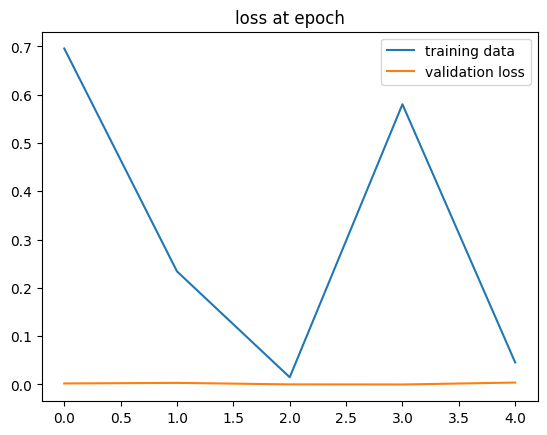

In [110]:
#graph the los at each epoch here
train_losses =[tl.item() for tl in train_losses]
plt.plot(train_losses,label="training data")
plt.plot(test_losses,label="validation loss")
plt.title("loss at epoch")
plt.legend()


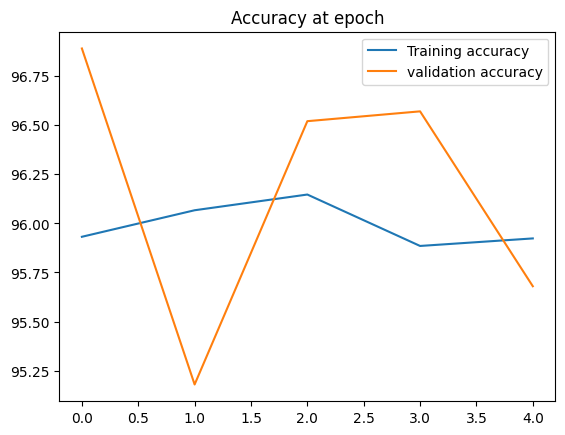

In [111]:
#graph accuracy
plt.plot([t/600 for t in train_correct],label="Training accuracy")
plt.plot([t/100 for t in test_correct],label="validation accuracy")
plt.title("Accuracy at epoch")
plt.legend()

In [112]:
text_load_everything =DataLoader(test_data,batch_size=10000,shuffle=False)

In [117]:
with torch.no_grad():
    correct = 0
    for X_test, y_test in text_load_everything:
        y_val = model(X_test)
        predicted = torch.max(y_val, 1)[1]

        # FIXED: Added .sum() here to get a single number for each batch
        correct += (predicted == y_test).sum()

In [119]:
correct.item()/len(test_data) *100

95.67999999999999

In [121]:
#grab and image here
test_data[4143]#tensor with and image in it

(tensor([[[0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
           0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
           0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
           0.0000, 0.0000, 0.0000, 0.0000],
          [0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
           0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
           0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
           0.0000, 0.0000, 0.0000, 0.0000],
          [0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
           0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
           0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
           0.0000, 0.0000, 0.0000, 0.0000],
          [0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
           0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
           0.0000, 0.0000, 0.0000, 0.0000, 

In [123]:
##grab just th data here
test_data[4143][0]

tensor([[[0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
          0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
          0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
          0.0000, 0.0000, 0.0000, 0.0000],
         [0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
          0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
          0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
          0.0000, 0.0000, 0.0000, 0.0000],
         [0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
          0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
          0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
          0.0000, 0.0000, 0.0000, 0.0000],
         [0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
          0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
          0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,

In [124]:
##reshape
test_data[4143][0].reshape(28,28)

tensor([[0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
         0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
         0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
         0.0000],
        [0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
         0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
         0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
         0.0000],
        [0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
         0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
         0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
         0.0000],
        [0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
         0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
         0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000

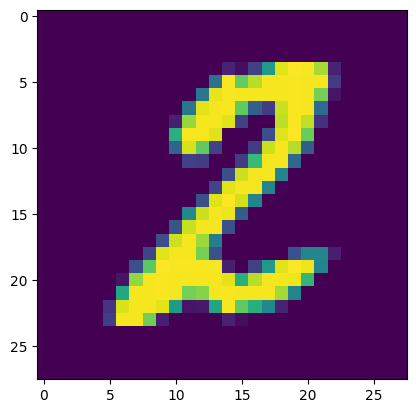

In [130]:
##showw image
plt.imshow(test_data[7587][0].reshape(28,28))

In [131]:
from torch.return_types import mode
##passimage through our moel here
model.eval()
with torch.no_grad():
 new_prediction =model(test_data[7587][0].view(1,1,28,28))#batch size of 1 1 color chanel of 28 by 28 size

In [128]:
new_prediction

tensor([[-3.4273e+01, -3.3466e+01, -3.8226e+01, -3.1739e+01, -1.9717e+01,
         -3.4026e+01, -1.0849e+02, -2.4185e+01, -1.3850e+01, -9.5367e-07]])

In [132]:
new_prediction.argmax()

tensor(2)